# Multivariate Reference-vs-Sobol Budget Study for `k = 0, 1, 2`

This notebook repeats the small-sample multivariate HAL budget study for orders `k = 0, 1, 2`. We use the exact normalizer as the reference for `k = 0`, then switch to a fixed midpoint normalizer for `k = 1` and `k = 2` because exact normalization is only available at `k = 0`. Each order is evaluated on the same folds and `M` grid so we can see what the midpoint-reference cases look like against different Sobol banks.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pathlib
import sys

from IPython.display import display
from sklearn.model_selection import KFold

cwd = pathlib.Path.cwd().resolve()
repo_root = next(
    path for path in (cwd, *cwd.parents)
    if (path / "src" / "haldensity").exists()
)
src_root = repo_root / "src"
if str(src_root) not in sys.path:
    sys.path.append(str(src_root))

np.random.seed(42)

from haldensity.multivariate import (
    BivariateTruncatedNormal,
    MultvarHAL,
    default_sobol_budget,
    exact_k0_cell_budget,
)

/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Generate A Small `n = 25` Sample

We keep the sample deliberately small so exact `k = 0` normalization remains cheap enough to use as a cross-validation reference curve, while a fixed midpoint bank is still practical as the reference for `k = 1` and `k = 2`.

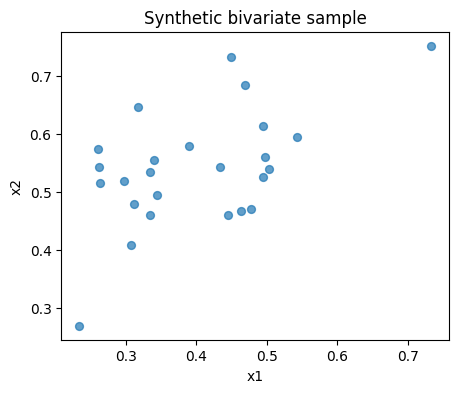

,x1,x2
0,0.477353,0.470246
1,0.262007,0.543342
2,0.733071,0.751574
3,0.433801,0.541965
4,0.494633,0.525311


In [2]:
dgp = BivariateTruncatedNormal(
    mean=(0.42, 0.58),
    covariance=[[0.018, 0.008], [0.008, 0.022]],
    lower=(0.0, 0.0),
    upper=(1.0, 1.0),
)
support = dgp.bounds
n_samples = 25
data = dgp.generate_samples(n_samples, seed=42)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(data["x1"], data["x2"], s=32, alpha=0.7)
ax.set_title("Synthetic bivariate sample")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
plt.show()

display(data.head())

## Shared CV Helpers

We use the package estimator directly and evaluate the same `M` grid for `k = 0, 1, 2`. Each order gets its own reference normalizer (`exact` for `k = 0`, `midpoint` for `k = 1, 2`) so the resulting Sobol comparison stays apples-to-apples within each order.

In [3]:
STUDY_CONFIG = {
    "orders": [0, 1, 2],
    "reference_normalizer_by_order": {0: "exact", 1: "midpoint", 2: "midpoint"},
    "cv_folds": 5,
    "cv_seed": 42,
    "quadrature_points_per_dim": 48,
    "norm_constraint_grid": np.geomspace(1.0, 256.0, 9),
    "sobol_budgets": [64, 128, 256, 512, 1024, 2048],
}
ESTIMATOR_BASE_CONFIG = {
    "support": support,
    "quadrature_points_per_dim": STUDY_CONFIG["quadrature_points_per_dim"],
    "solver": "MOSEK",
    "use_secondary_solver": True,
    "selection_tol": 1e-4,
}

kfold = KFold(
    n_splits=STUDY_CONFIG["cv_folds"],
    shuffle=True,
    random_state=STUDY_CONFIG["cv_seed"],
)
default_budget = default_sobol_budget(len(support))
midpoint_reference_budget = STUDY_CONFIG["quadrature_points_per_dim"] ** len(support)

k0_exact_fold_budget_rows = []
for fold_idx, (train_idx, _) in enumerate(kfold.split(data), start=1):
    train_fold = data.iloc[train_idx].reset_index(drop=True)
    k0_exact_fold_budget_rows.append(
        {
            "fold": fold_idx,
            "train_size": len(train_fold),
            "exact_cell_budget": exact_k0_cell_budget(support, train_fold),
        }
    )
k0_exact_fold_budget_df = pd.DataFrame(k0_exact_fold_budget_rows)

reference_setup_rows = []
for order in STUDY_CONFIG["orders"]:
    reference_method_name = STUDY_CONFIG["reference_normalizer_by_order"][order]
    if reference_method_name == "exact":
        reference_bank_size_full_sample = exact_k0_cell_budget(support, data)
        reference_bank_size_fold_min = int(k0_exact_fold_budget_df["exact_cell_budget"].min())
        reference_bank_size_fold_max = int(k0_exact_fold_budget_df["exact_cell_budget"].max())
    else:
        reference_bank_size_full_sample = midpoint_reference_budget
        reference_bank_size_fold_min = midpoint_reference_budget
        reference_bank_size_fold_max = midpoint_reference_budget

    reference_setup_rows.append(
        {
            "k": order,
            "reference_normalizer": reference_method_name,
            "reference_bank_size_full_sample": int(reference_bank_size_full_sample),
            "reference_bank_over_default": float(reference_bank_size_full_sample / default_budget),
            "reference_bank_size_fold_min": int(reference_bank_size_fold_min),
            "reference_bank_size_fold_max": int(reference_bank_size_fold_max),
            "default_sobol_budget_2d": int(default_budget),
        }
    )

reference_setup_df = pd.DataFrame(reference_setup_rows).sort_values("k").reset_index(drop=True)
study_summary = pd.Series(
    {
        "training_samples": n_samples,
        "orders_studied": tuple(STUDY_CONFIG["orders"]),
        "default_sobol_budget_2d": int(default_budget),
        "midpoint_reference_budget_2d": int(midpoint_reference_budget),
    },
    name="value",
)

display(study_summary.to_frame())
display(reference_setup_df)
display(k0_exact_fold_budget_df)


def average_log_likelihood(model, evaluation_data):
    density = np.clip(model.get_density_at_points(evaluation_data), 1e-12, None)
    return float(np.mean(np.log(density)))


cv_cache = {}


def reference_method(order):
    return STUDY_CONFIG["reference_normalizer_by_order"][int(order)]


def reference_overrides(order):
    return {"normalizer": reference_method(order)}


def cv_stats(order, norm_constraint, estimator_overrides=None):
    estimator_overrides = {} if estimator_overrides is None else dict(estimator_overrides)
    override_key = tuple(sorted(estimator_overrides.items()))
    cache_key = (int(order), float(np.round(float(norm_constraint), 12)), override_key)
    cached = cv_cache.get(cache_key)
    if cached is not None:
        return cached

    estimator_config = {**ESTIMATOR_BASE_CONFIG, **estimator_overrides}
    fold_scores = []
    selected_counts = []
    normalizer_sizes = []
    normalizer_methods = []

    for train_idx, val_idx in kfold.split(data):
        train_fold = data.iloc[train_idx].reset_index(drop=True)
        val_fold = data.iloc[val_idx].reset_index(drop=True)
        model = MultvarHAL(
            k=order,
            norm_constraint=float(norm_constraint),
            **estimator_config,
        ).fit(train_fold)
        fold_scores.append(average_log_likelihood(model, val_fold))
        summary = model.summary()
        selected_counts.append(summary["selected_basis_count"])
        normalizer_sizes.append(summary["normalizer_size"])
        normalizer_methods.append(summary["normalizer_method_used"])

    stats = {
        "cv_mean": float(np.mean(fold_scores)),
        "cv_sd": float(np.std(fold_scores, ddof=1)) if len(fold_scores) > 1 else 0.0,
        "selected_basis_count_median": int(np.median(selected_counts)),
        "normalizer_method": normalizer_methods[0],
        "normalizer_size_median": int(np.median(normalizer_sizes)),
    }
    cv_cache[cache_key] = stats
    return stats


def build_cv_curve(order, curve_label, estimator_overrides=None):
    rows = []
    for norm_constraint in STUDY_CONFIG["norm_constraint_grid"]:
        rows.append(
            {
                "curve_label": curve_label,
                "norm_constraint": float(norm_constraint),
                **cv_stats(order, norm_constraint, estimator_overrides=estimator_overrides),
            }
        )
    return pd.DataFrame(rows)

,value
training_samples,25
orders_studied,"(0, 1, 2)"
default_sobol_budget_2d,512
midpoint_reference_budget_2d,2304


,k,reference_normalizer,reference_bank_size_full_sample,reference_bank_over_default,reference_bank_size_fold_min,reference_bank_size_fold_max,default_sobol_budget_2d
0,0,exact,676,1.320312,441,441,512
1,1,midpoint,2304,4.500000,2304,2304,512
2,2,midpoint,2304,4.500000,2304,2304,512


,fold,train_size,exact_cell_budget
0,1,20,441
1,2,20,441
2,3,20,441
3,4,20,441
4,5,20,441


## Order-Specific Reference CV Curves

For `k = 0` we can still use the exact cell normalizer as the reference. For `k = 1` and `k = 2`, exact normalization is unavailable, so we use a dense midpoint bank as the reference curve and check whether each order still has a clear interior peak.

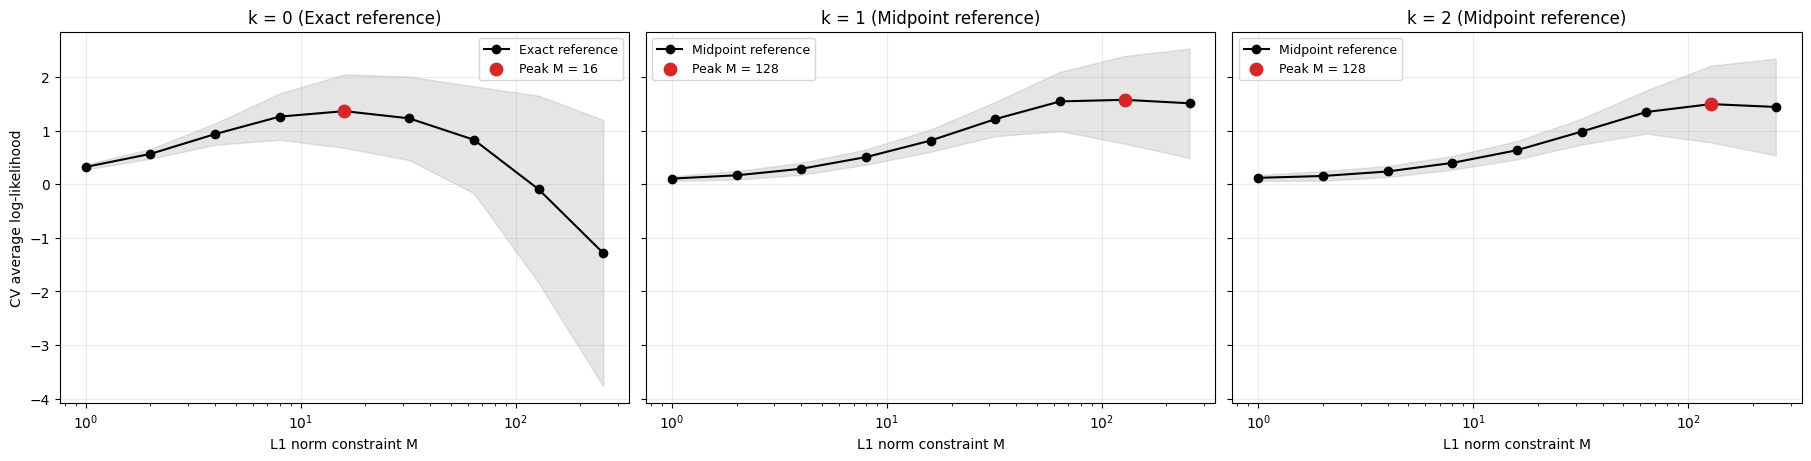

,k,reference_normalizer,reference_peak_M,reference_peak_cv_mean,reference_peak_cv_sd,curve_has_interior_peak,cv_fold_normalizer_size_median
0,0,exact,16.0,1.364414,0.686252,True,441
1,1,midpoint,128.0,1.575745,0.818628,True,2304
2,2,midpoint,128.0,1.495951,0.716705,True,2304


,k,reference_normalizer,norm_constraint,cv_mean,cv_sd,selected_basis_count_median,normalizer_size_median
0,0,exact,1.0,0.322209,0.049962,5,441
1,0,exact,2.0,0.565979,0.089964,6,441
2,0,exact,4.0,0.935952,0.200970,8,441
3,0,exact,8.0,1.262157,0.433052,12,441
4,0,exact,16.0,1.364414,0.686252,23,441
5,0,exact,32.0,1.229840,0.779841,33,441
6,0,exact,64.0,0.830265,0.998387,46,441
7,0,exact,128.0,-0.093824,1.746963,58,441
8,0,exact,256.0,-1.285741,2.484789,61,441
9,1,midpoint,1.0,0.105193,0.042112,2,2304


In [4]:
reference_results = {}
reference_summary_rows = []
reference_curve_frames = []

fig, axes = plt.subplots(
    1,
    len(STUDY_CONFIG["orders"]),
    figsize=(6 * len(STUDY_CONFIG["orders"]), 4.5),
    sharey=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes)

for ax, order in zip(axes, STUDY_CONFIG["orders"]):
    order_reference_method = reference_method(order)
    reference_curve_df = build_cv_curve(
        order,
        curve_label=f"{order_reference_method}_reference",
        estimator_overrides=reference_overrides(order),
    )
    reference_peak_row = reference_curve_df.loc[reference_curve_df["cv_mean"].idxmax()].copy()
    reference_peak_M = float(reference_peak_row["norm_constraint"])

    reference_results[order] = {
        "reference_method": order_reference_method,
        "reference_curve_df": reference_curve_df,
        "reference_peak_row": reference_peak_row,
        "reference_peak_M": reference_peak_M,
    }
    reference_curve_frames.append(
        reference_curve_df.assign(k=order, reference_normalizer=order_reference_method)
    )
    reference_summary_rows.append(
        {
            "k": order,
            "reference_normalizer": order_reference_method,
            "reference_peak_M": reference_peak_M,
            "reference_peak_cv_mean": float(reference_peak_row["cv_mean"]),
            "reference_peak_cv_sd": float(reference_peak_row["cv_sd"]),
            "curve_has_interior_peak": bool(
                reference_peak_M > reference_curve_df["norm_constraint"].min()
                and reference_peak_M < reference_curve_df["norm_constraint"].max()
            ),
            "cv_fold_normalizer_size_median": int(reference_curve_df["normalizer_size_median"].iloc[0]),
        }
    )

    ax.plot(
        reference_curve_df["norm_constraint"],
        reference_curve_df["cv_mean"],
        marker="o",
        color="black",
        label=f"{order_reference_method.title()} reference",
    )
    ax.fill_between(
        reference_curve_df["norm_constraint"],
        reference_curve_df["cv_mean"] - reference_curve_df["cv_sd"],
        reference_curve_df["cv_mean"] + reference_curve_df["cv_sd"],
        color="gray",
        alpha=0.2,
    )
    ax.scatter(
        [reference_peak_M],
        [reference_peak_row["cv_mean"]],
        color="tab:red",
        s=80,
        label=f"Peak M = {reference_peak_M:.0f}",
        zorder=5,
    )
    ax.set_xscale("log")
    ax.set_title(f"k = {order} ({order_reference_method.title()} reference)")
    ax.set_xlabel("L1 norm constraint M")
    ax.grid(alpha=0.25)
    ax.legend(loc="best", fontsize=9)

axes[0].set_ylabel("CV average log-likelihood")
plt.show()

reference_summary_df = pd.DataFrame(reference_summary_rows).sort_values("k").reset_index(drop=True)
reference_curve_table_df = (
    pd.concat(reference_curve_frames, ignore_index=True)
    .sort_values(["k", "norm_constraint"])
    .reset_index(drop=True)
)

display(reference_summary_df)
display(
    reference_curve_table_df[
        [
            "k",
            "reference_normalizer",
            "norm_constraint",
            "cv_mean",
            "cv_sd",
            "selected_basis_count_median",
            "normalizer_size_median",
        ]
    ]
)

## Sobol Budget Curves Against Each Reference

Next we rerun the same `M` grid with explicit Sobol budgets and overlay those curves on top of the order-specific reference curve. For `k = 1, 2` this answers the midpoint-versus-Sobol question directly because the basis, folds, and `M` grid all stay fixed and only the normalizer bank changes.

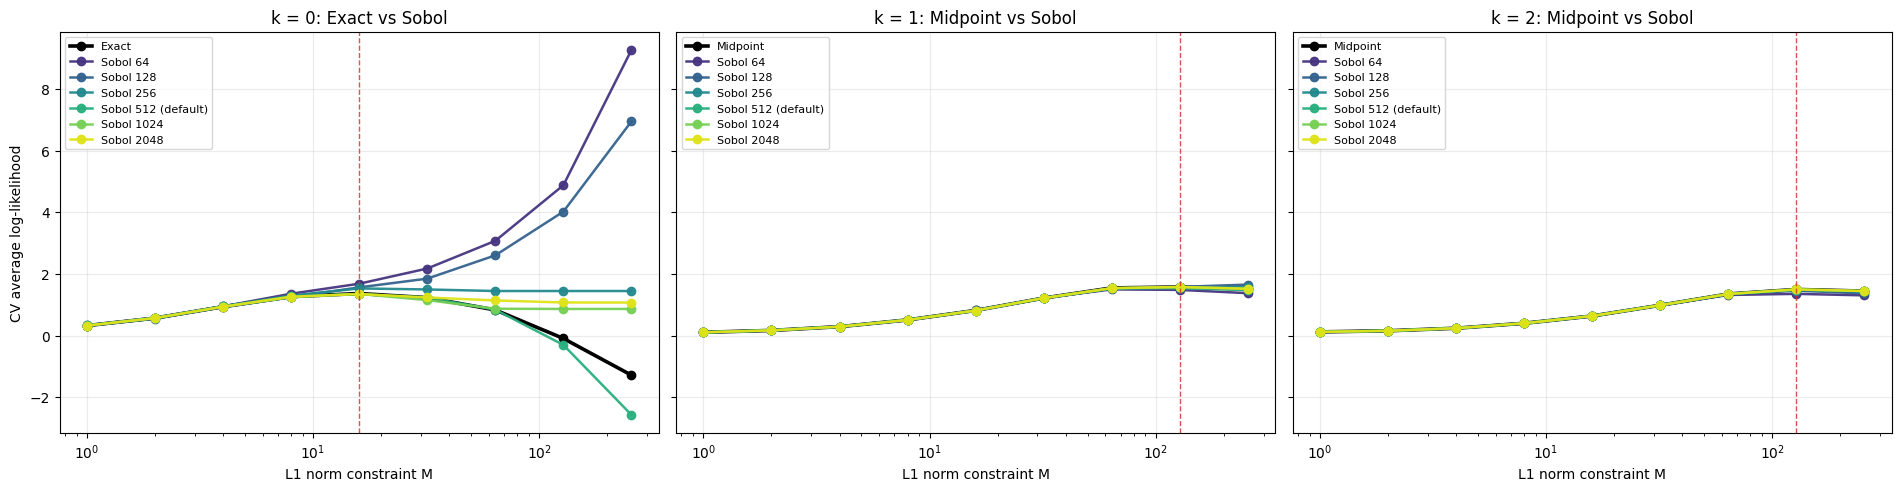

,k,sobol_budget,sobol_peak_M,sobol_peak_cv_mean
0,0,64,256.0,9.269383
1,0,128,256.0,6.950842
2,0,256,16.0,1.529080
3,0,512,16.0,1.349044
4,0,1024,16.0,1.350484
5,0,2048,16.0,1.347666
6,1,64,64.0,1.498193
7,1,128,256.0,1.653694
8,1,256,128.0,1.569443
9,1,512,128.0,1.537352


In [5]:
sobol_results = {}
sobol_curve_frames = []

fig, axes = plt.subplots(
    1,
    len(STUDY_CONFIG["orders"]),
    figsize=(6.3 * len(STUDY_CONFIG["orders"]), 4.8),
    sharey=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes)

color_values = plt.cm.viridis(np.linspace(0.15, 0.95, len(STUDY_CONFIG["sobol_budgets"])))
for ax, order in zip(axes, STUDY_CONFIG["orders"]):
    order_reference_method = reference_results[order]["reference_method"]
    reference_curve_df = reference_results[order]["reference_curve_df"]
    reference_peak_M = reference_results[order]["reference_peak_M"]
    order_sobol_frames = []

    ax.plot(
        reference_curve_df["norm_constraint"],
        reference_curve_df["cv_mean"],
        color="black",
        linewidth=2.6,
        marker="o",
        label=order_reference_method.title(),
    )

    for color, sobol_budget in zip(color_values, STUDY_CONFIG["sobol_budgets"]):
        curve = build_cv_curve(
            order,
            curve_label=f"sobol_{sobol_budget}",
            estimator_overrides={"normalizer": "sobol", "sobol_budget": sobol_budget},
        )
        curve = curve.assign(
            k=order,
            sobol_budget=sobol_budget,
            reference_normalizer=order_reference_method,
        )
        order_sobol_frames.append(curve)

        label = f"Sobol {sobol_budget}"
        if sobol_budget == default_budget:
            label += " (default)"
        ax.plot(
            curve["norm_constraint"],
            curve["cv_mean"],
            color=color,
            linewidth=1.8,
            marker="o",
            alpha=0.95,
            label=label,
        )

    sobol_results[order] = pd.concat(order_sobol_frames, ignore_index=True)
    sobol_curve_frames.append(sobol_results[order])

    ax.axvline(reference_peak_M, color="tab:red", linestyle="--", linewidth=1.0, alpha=0.8)
    ax.set_xscale("log")
    ax.set_title(f"k = {order}: {order_reference_method.title()} vs Sobol")
    ax.set_xlabel("L1 norm constraint M")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper left", fontsize=8)

axes[0].set_ylabel("CV average log-likelihood")
plt.show()

sobol_curve_df = (
    pd.concat(sobol_curve_frames, ignore_index=True)
    .sort_values(["k", "sobol_budget", "norm_constraint"])
    .reset_index(drop=True)
)
sobol_peak_df = (
    sobol_curve_df.sort_values(["k", "sobol_budget", "cv_mean"], ascending=[True, True, False])
    .groupby(["k", "sobol_budget"], as_index=False)
    .first()[["k", "sobol_budget", "norm_constraint", "cv_mean"]]
    .rename(columns={"norm_constraint": "sobol_peak_M", "cv_mean": "sobol_peak_cv_mean"})
)

display(sobol_peak_df)

## Budget Adequacy Summary

To judge how much Sobol budget is enough, we compare each Sobol curve to its order-specific reference over the full `M` grid and over a smaller practical region up to `2 ×` the reference peak. The practical region is the more relevant one if we only care about the neighborhood where the reference curve is maximized.

,k,reference_normalizer,reference_peak_M,sobol_budget,budget_over_default,sobol_peak_M,sobol_peak_matches_reference,max_abs_gap_full,rmse_full,max_abs_gap_to_2x_peak,rmse_to_2x_peak
0,0,exact,16.0,64,0.125,256.0,False,10.555124,3.974577,0.317303,0.148390
1,0,exact,16.0,128,0.250,256.0,False,8.236583,3.133050,0.198525,0.089793
2,0,exact,16.0,256,0.500,16.0,True,2.730773,1.069906,0.164666,0.075521
3,0,exact,16.0,512,1.000,16.0,True,1.288659,0.435321,0.015369,0.008943
4,0,exact,16.0,1024,2.000,16.0,True,2.148942,0.784740,0.016756,0.009833
5,0,exact,16.0,2048,4.000,16.0,True,2.357374,0.882734,0.016748,0.007617
6,1,midpoint,128.0,64,0.125,64.0,False,0.135835,0.057329,0.094024,0.037297
7,1,midpoint,128.0,128,0.250,256.0,False,0.142756,0.047966,0.016928,0.006397
8,1,midpoint,128.0,256,0.500,128.0,True,0.056969,0.019879,0.015592,0.006237
9,1,midpoint,128.0,512,1.000,128.0,True,0.038393,0.018090,0.038393,0.014792


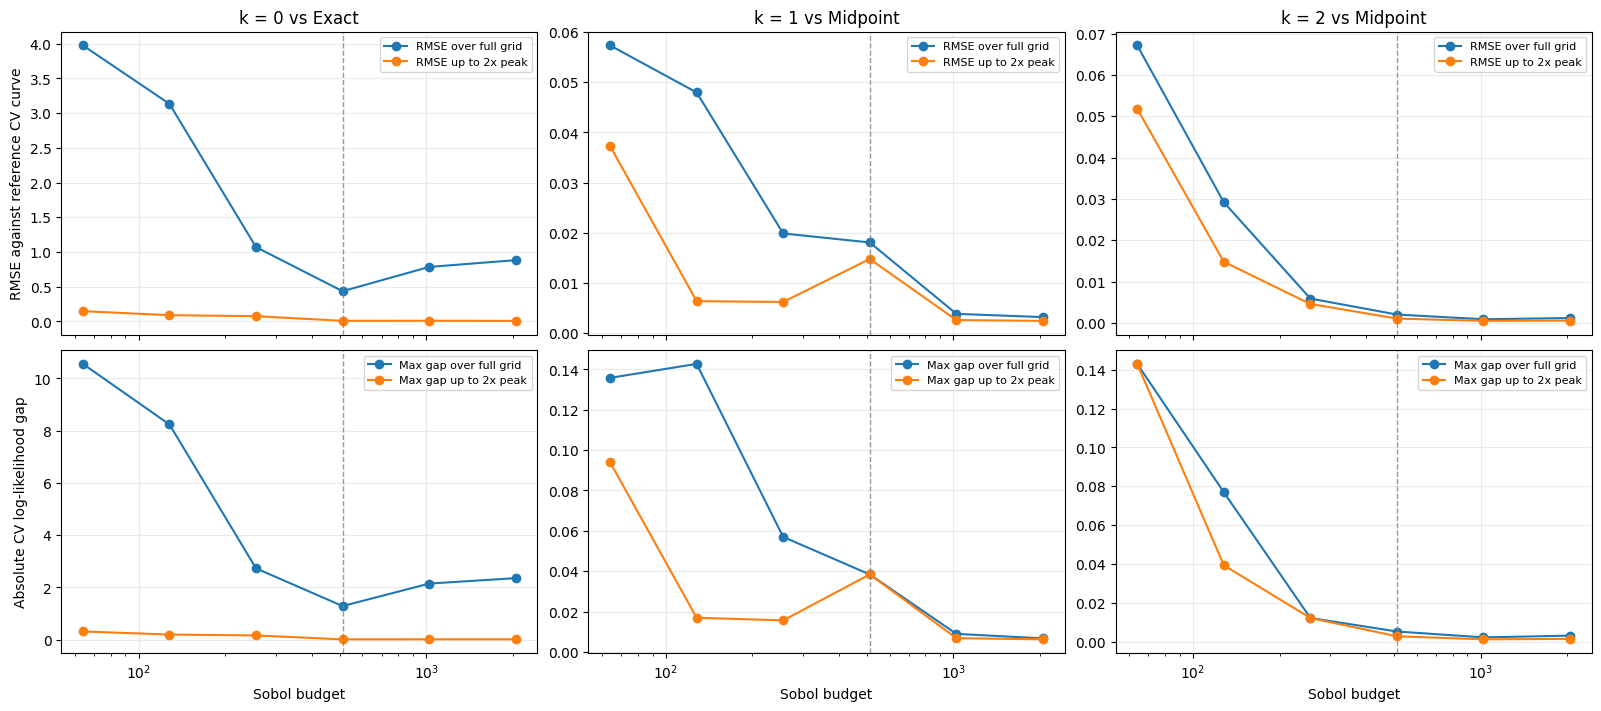

In [6]:
budget_summary_rows = []
for order in STUDY_CONFIG["orders"]:
    order_reference_method = reference_results[order]["reference_method"]
    reference_curve_df = reference_results[order]["reference_curve_df"].sort_values("norm_constraint")
    reference_peak_M = reference_results[order]["reference_peak_M"]
    order_sobol_df = sobol_results[order]

    for sobol_budget in STUDY_CONFIG["sobol_budgets"]:
        curve = order_sobol_df.loc[order_sobol_df["sobol_budget"] == sobol_budget].sort_values("norm_constraint")
        merged = reference_curve_df[["norm_constraint", "cv_mean"]].merge(
            curve[["norm_constraint", "cv_mean"]],
            on="norm_constraint",
            suffixes=("_reference", "_sobol"),
        )
        merged["abs_gap"] = np.abs(merged["cv_mean_reference"] - merged["cv_mean_sobol"])
        practical = merged.loc[merged["norm_constraint"] <= 2.0 * reference_peak_M].copy()
        sobol_peak_row = curve.loc[curve["cv_mean"].idxmax()]
        budget_summary_rows.append(
            {
                "k": order,
                "reference_normalizer": order_reference_method,
                "reference_peak_M": float(reference_peak_M),
                "sobol_budget": sobol_budget,
                "budget_over_default": float(sobol_budget / default_budget),
                "sobol_peak_M": float(sobol_peak_row["norm_constraint"]),
                "sobol_peak_matches_reference": bool(np.isclose(float(sobol_peak_row["norm_constraint"]), reference_peak_M)),
                "max_abs_gap_full": float(merged["abs_gap"].max()),
                "rmse_full": float(np.sqrt(np.mean(np.square(merged["abs_gap"])))),
                "max_abs_gap_to_2x_peak": float(practical["abs_gap"].max()),
                "rmse_to_2x_peak": float(np.sqrt(np.mean(np.square(practical["abs_gap"])))),
            }
        )

budget_summary_df = pd.DataFrame(budget_summary_rows).sort_values(["k", "sobol_budget"]).reset_index(drop=True)
display(budget_summary_df)

fig, axes = plt.subplots(
    2,
    len(STUDY_CONFIG["orders"]),
    figsize=(5.3 * len(STUDY_CONFIG["orders"]), 7.0),
    sharex="col",
    constrained_layout=True,
)
axes = np.asarray(axes)
if axes.ndim == 1:
    axes = axes.reshape(2, 1)

for col_idx, order in enumerate(STUDY_CONFIG["orders"]):
    order_reference_method = reference_results[order]["reference_method"]
    order_budget_df = budget_summary_df.loc[budget_summary_df["k"] == order].sort_values("sobol_budget")

    axes[0, col_idx].plot(order_budget_df["sobol_budget"], order_budget_df["rmse_full"], marker="o", label="RMSE over full grid")
    axes[0, col_idx].plot(order_budget_df["sobol_budget"], order_budget_df["rmse_to_2x_peak"], marker="o", label="RMSE up to 2x peak")
    axes[0, col_idx].axvline(default_budget, color="gray", linestyle="--", linewidth=1.0, alpha=0.8)
    axes[0, col_idx].set_xscale("log")
    axes[0, col_idx].set_title(f"k = {order} vs {order_reference_method.title()}")
    if col_idx == 0:
        axes[0, col_idx].set_ylabel("RMSE against reference CV curve")
    axes[0, col_idx].grid(alpha=0.25)
    axes[0, col_idx].legend(loc="best", fontsize=8)

    axes[1, col_idx].plot(order_budget_df["sobol_budget"], order_budget_df["max_abs_gap_full"], marker="o", label="Max gap over full grid")
    axes[1, col_idx].plot(order_budget_df["sobol_budget"], order_budget_df["max_abs_gap_to_2x_peak"], marker="o", label="Max gap up to 2x peak")
    axes[1, col_idx].axvline(default_budget, color="gray", linestyle="--", linewidth=1.0, alpha=0.8)
    axes[1, col_idx].set_xscale("log")
    axes[1, col_idx].set_xlabel("Sobol budget")
    if col_idx == 0:
        axes[1, col_idx].set_ylabel("Absolute CV log-likelihood gap")
    axes[1, col_idx].grid(alpha=0.25)
    axes[1, col_idx].legend(loc="best", fontsize=8)

plt.show()

## Takeaways

The order-specific reference curve answers the stability question directly, and the gap table answers the budget question. The short summary below makes it easy to compare the best budget for each order, with a second table focusing only on the midpoint-reference cases `k = 1, 2`.

In [7]:
summary_rows = []
for order in STUDY_CONFIG["orders"]:
    order_reference_method = reference_results[order]["reference_method"]
    order_budget_df = (
        budget_summary_df.loc[budget_summary_df["k"] == order]
        .sort_values("sobol_budget")
        .reset_index(drop=True)
    )
    default_budget_row = order_budget_df.loc[order_budget_df["sobol_budget"] == default_budget].iloc[0]
    best_full_budget = int(order_budget_df.loc[order_budget_df["rmse_full"].idxmin(), "sobol_budget"])
    best_practical_budget = int(order_budget_df.loc[order_budget_df["rmse_to_2x_peak"].idxmin(), "sobol_budget"])
    summary_rows.append(
        {
            "k": order,
            "reference_normalizer": order_reference_method,
            "reference_peak_M": float(reference_results[order]["reference_peak_M"]),
            "reference_bank_size_full_sample": int(
                reference_setup_df.loc[
                    reference_setup_df["k"] == order,
                    "reference_bank_size_full_sample",
                ].iloc[0]
            ),
            "best_sobol_budget_full_grid": best_full_budget,
            "best_sobol_budget_up_to_2x_peak": best_practical_budget,
            "default_sobol_budget_2d": int(default_budget),
            "default_budget_peak_matches_reference": bool(default_budget_row["sobol_peak_matches_reference"]),
            "default_budget_rmse_to_2x_peak": float(default_budget_row["rmse_to_2x_peak"]),
            "default_budget_max_gap_to_2x_peak": float(default_budget_row["max_abs_gap_to_2x_peak"]),
        }
    )

summary_notes_df = pd.DataFrame(summary_rows).sort_values("k").reset_index(drop=True)
midpoint_summary_df = summary_notes_df.loc[
    summary_notes_df["reference_normalizer"] == "midpoint",
    [
        "k",
        "reference_peak_M",
        "best_sobol_budget_full_grid",
        "best_sobol_budget_up_to_2x_peak",
        "default_sobol_budget_2d",
        "default_budget_peak_matches_reference",
        "default_budget_rmse_to_2x_peak",
        "default_budget_max_gap_to_2x_peak",
    ],
].reset_index(drop=True)

display(summary_notes_df)
display(midpoint_summary_df)

,k,reference_normalizer,reference_peak_M,reference_bank_size_full_sample,best_sobol_budget_full_grid,best_sobol_budget_up_to_2x_peak,default_sobol_budget_2d,default_budget_peak_matches_reference,default_budget_rmse_to_2x_peak,default_budget_max_gap_to_2x_peak
0,0,exact,16.0,676,512,2048,512,True,0.008943,0.015369
1,1,midpoint,128.0,2304,2048,2048,512,True,0.014792,0.038393
2,2,midpoint,128.0,2304,1024,1024,512,True,0.001039,0.002819


,k,reference_peak_M,best_sobol_budget_full_grid,best_sobol_budget_up_to_2x_peak,default_sobol_budget_2d,default_budget_peak_matches_reference,default_budget_rmse_to_2x_peak,default_budget_max_gap_to_2x_peak
0,1,128.0,2048,2048,512,True,0.014792,0.038393
1,2,128.0,1024,1024,512,True,0.001039,0.002819
